# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [105]:
#Import all the necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')


# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [106]:
colnames = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']
pima_df = pd.read_csv("pima-indians-diabetes.data", names= colnames)

In [107]:
pima_df.head(5).T

,0,1,2,3,4
Pregnancies,6.000,1.000,8.000,1.000,0.000
Glucose,148.000,85.000,183.000,89.000,137.000
BloodPressure,72.000,66.000,64.000,66.000,40.000
SkinThickness,35.000,29.000,0.000,23.000,35.000
Insulin,0.000,0.000,0.000,94.000,168.000
BMI,33.600,26.600,23.300,28.100,43.100
DPF,0.627,0.351,0.672,0.167,2.288
Age,50.000,31.000,32.000,21.000,33.000
Outcome,1.000,0.000,1.000,0.000,1.000


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [108]:
print(pima_df.head(10))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI    DPF  \
0            6      148             72             35        0  33.6  0.627   
1            1       85             66             29        0  26.6  0.351   
2            8      183             64              0        0  23.3  0.672   
3            1       89             66             23       94  28.1  0.167   
4            0      137             40             35      168  43.1  2.288   
5            5      116             74              0        0  25.6  0.201   
6            3       78             50             32       88  31.0  0.248   
7           10      115              0              0        0  35.3  0.134   
8            2      197             70             45      543  30.5  0.158   
9            8      125             96              0        0   0.0  0.232   

   Age  Outcome  
0   50        1  
1   31        0  
2   32        1  
3   21        0  
4   33        1  
5   30        0  
6   

# Q3 Print the datatypes of each column and the shape of the dataset 

In [109]:
print('Data types in the dataframe are\n',pima_df.dtypes)
print('Shape of the dataframe is',pima_df.shape)

Data types in the dataframe are
 Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
DPF              float64
Age                int64
Outcome            int64
dtype: object
Shape of the dataframe is (768, 9)


There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

                                    EXPLORATORY DATA ANALYSIS

Function used to find zeroes: pima_df[pima_df['Age'] == 0] used this function to identify for all columns if they had 0 data. 
The following is the finding

Pregnancies - Can be 0. A woman might be have been 0 time pregnant

Glucose - Cannot be 0. Needs to be updated by median

BloodPressure - Cannot be 0. Needs to be updated by median

SkinThickness - Cannot be 0. Needs to be updated by median

Insulin - Cannot be 0. Needs to be updated by median

BMI - Cannot be 0. Needs to be updated by median

DPF - No zeroes were found

Age - No zeroes were found

Outcome - Has zeroes but since its the output variable (Variable to predict), do not change





In [110]:
pima_df['Glucose'] = pima_df['Glucose'].replace(0,pima_df['Glucose'].median())
pima_df['BloodPressure'] = pima_df['BloodPressure'].replace(0,pima_df['BloodPressure'].median())
pima_df['SkinThickness'] = pima_df['SkinThickness'].replace(0,pima_df['SkinThickness'].median())
pima_df['Insulin'] = pima_df['Insulin'].replace(0,pima_df['Insulin'].median())
pima_df['BMI'] = pima_df['BMI'].replace(0,pima_df['BMI'].median())

In [111]:
pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


# Q5 Print the descriptive statistics of each & every column using describe() function

In [112]:
print(pima_df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      27.334635   94.652344   
std       3.369578   30.438286      12.096642       9.229014  105.547598   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      23.000000   30.500000   
50%       3.000000  117.000000      72.000000      23.000000   31.250000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI         DPF         Age     Outcome  
count  768.000000  768.000000  768.000000  768.000000  
mean    32.450911    0.471876   33.240885    0.348958  
std      6.875366    0.331329   11.760232    0.476951  
min     18.200000    0.078000   21.000000    0.000000  
25%     27.500000    0.243750   24.

# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

(array([500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 268.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 10 Patch objects>)

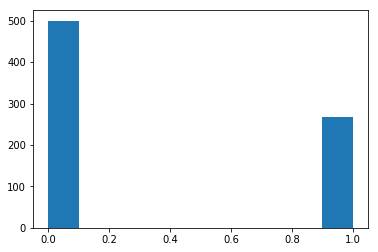

In [113]:
plt.hist(pima_df['Outcome'])

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


Using the plot - infer the relationship between different variables

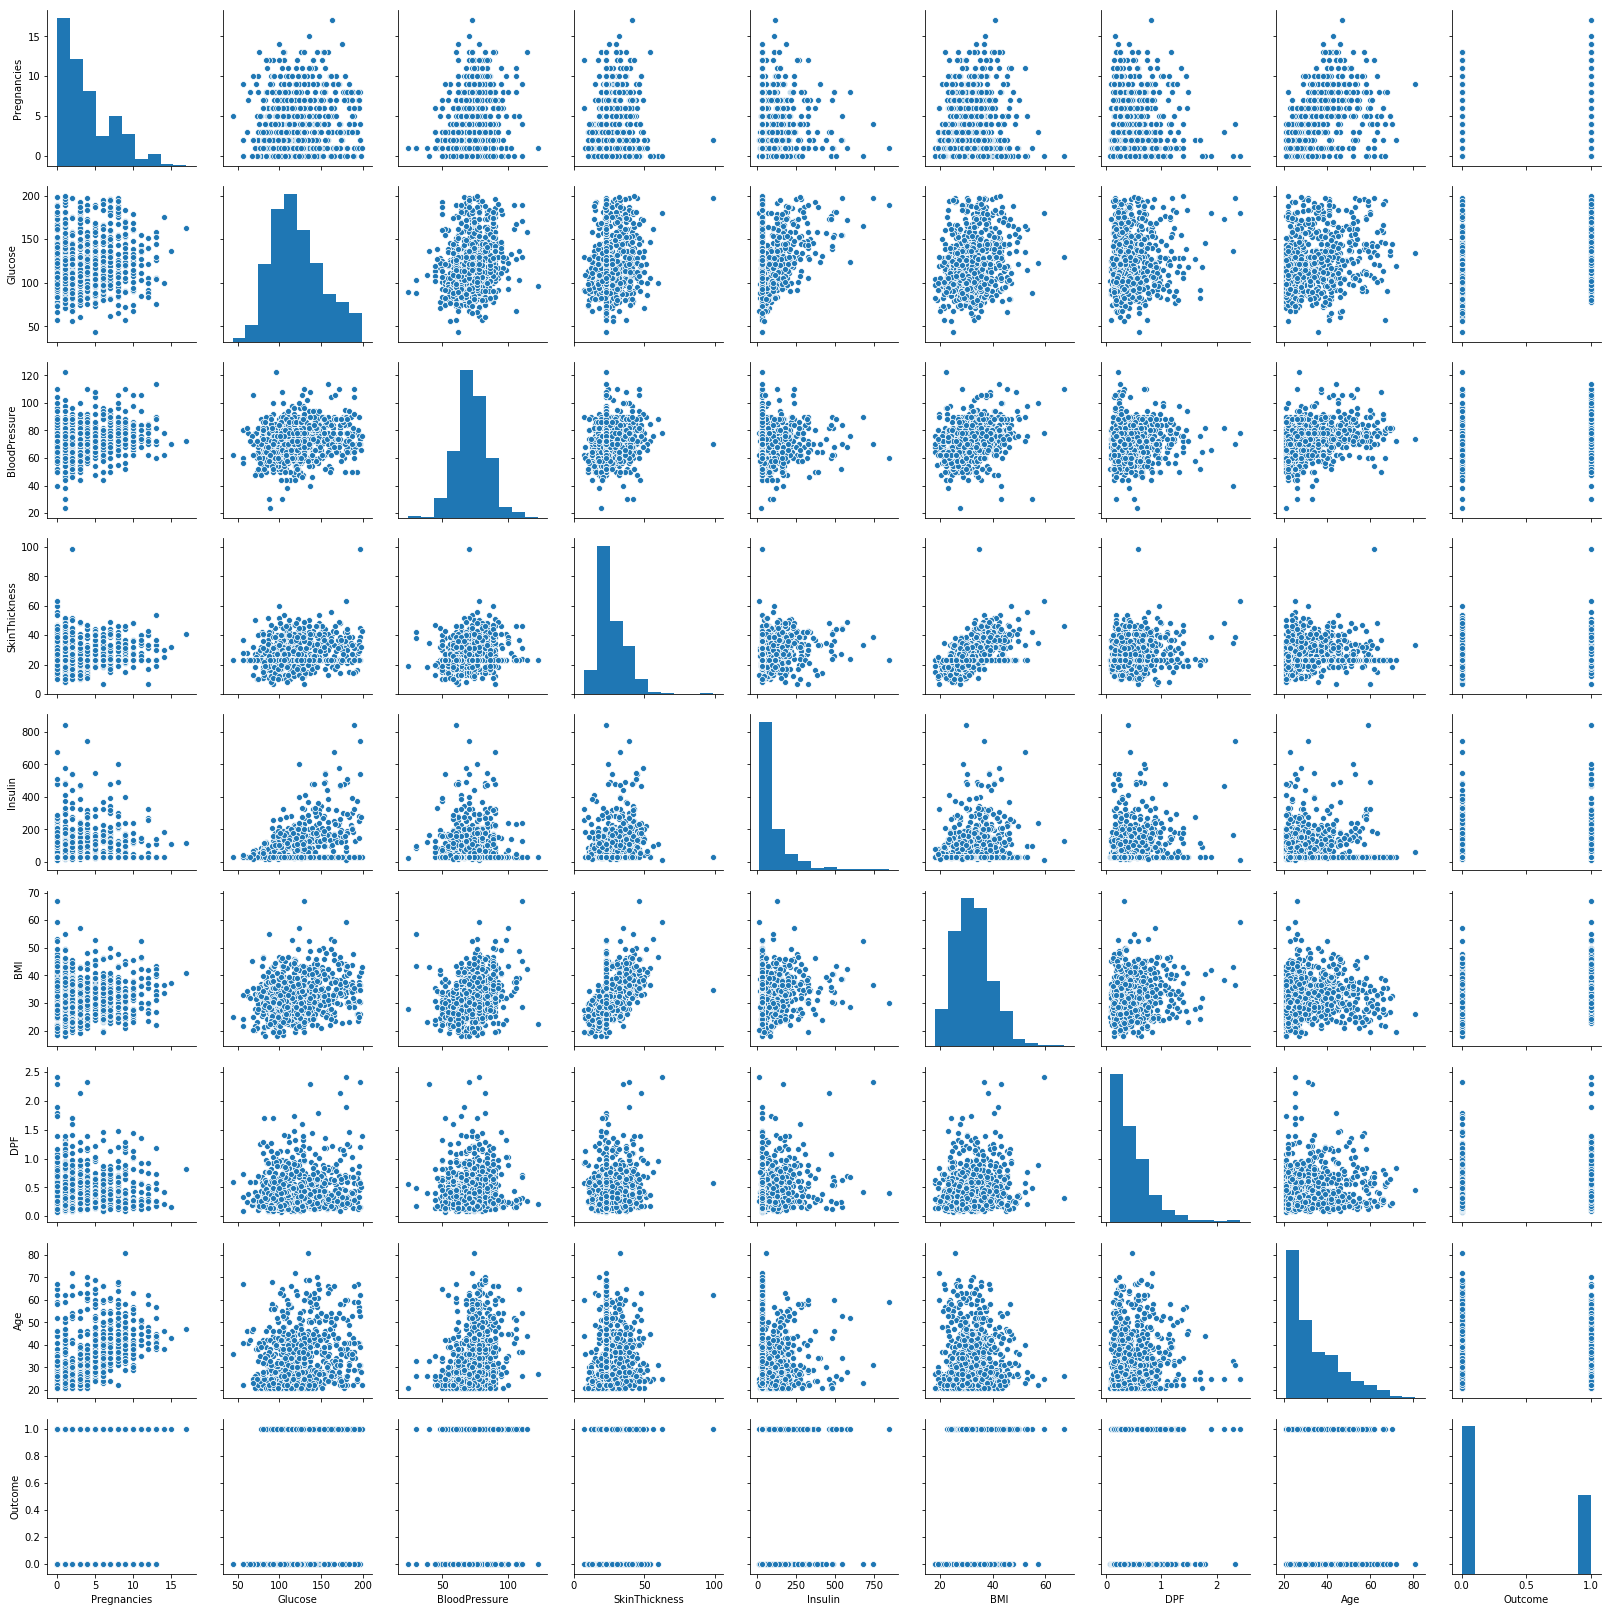

In [114]:
# Pairplot using sns
sns.pairplot(pima_df)

In [115]:
pima_df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.032568,-0.055697,0.021546,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.172143,0.357573,0.231400,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.147809,-0.028721,0.281132,-0.002378,0.324915,0.165723
SkinThickness,0.032568,0.172143,0.147809,1.000000,0.238188,0.546951,0.142977,0.054514,0.189065
Insulin,-0.055697,0.357573,-0.028721,0.238188,1.000000,0.189022,0.178029,-0.015413,0.148457
BMI,0.021546,0.231400,0.281132,0.546951,0.189022,1.000000,0.153506,0.025744,0.312249
DPF,-0.033523,0.137327,-0.002378,0.142977,0.178029,0.153506,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.054514,-0.015413,0.025744,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.189065,0.148457,0.312249,0.173844,0.238356,1.000000


In [116]:
#From SNS pairplot Data for insulin is highly skewed. Long right tail
#From df.corr() Glucose is highly correlated to outcome and will have good effect on outcome prediction

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [117]:
X = pima_df.drop(['Outcome'], axis=1)
y = pima_df['Outcome']

In [118]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [119]:
model1=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
model1.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

# Q10 Print the accuracy of the model & print the confusion matrix 

In [120]:
y_predict = model1.predict(X_test)

Print the feature importance of the decision model - Optional

In [121]:
acc = accuracy_score(y_test , y_predict)
print('Accuracy score is ', acc)

Accuracy score is  0.7316017316017316


In [122]:
cm=metrics.confusion_matrix(y_test,y_predict)
print('Confusion metrics can be seen below\n',cm)

Confusion metrics can be seen below
 [[106  41]
 [ 21  63]]


# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [123]:
model2 = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=0)
model2.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [124]:
y_predict2 = model2.predict(X_test)

In [125]:
acc = accuracy_score(y_test , y_predict2)
print('Accuracy score is ', acc)

Accuracy score is  0.7489177489177489


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [126]:
baseLogReg = LogisticRegression(random_state=2)
adaBoostLogReg = AdaBoostClassifier(base_estimator=baseLogReg,n_estimators=50,random_state=2)
adaBoostLogReg.fit(X_train,y_train)
y_predict3 = adaBoostLogReg.predict(X_test)

In [127]:
acc = accuracy_score(y_test , y_predict3)
print('Accuracy score is ', acc)

Accuracy score is  0.7489177489177489


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [128]:
bagClassifier = BaggingClassifier(base_estimator=baseLogReg,n_estimators=15,random_state=2)
bagClassifier.fit(X_train,y_train)

BaggingClassifier(base_estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=2, solver='warn',
          tol=0.0001, verbose=0, warm_start=False),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=15, n_jobs=None, oob_score=False,
         random_state=2, verbose=0, warm_start=False)

In [129]:
y_predict4 = bagClassifier.predict(X_test)

In [130]:
acc = accuracy_score(y_test , y_predict4)
print('Accuracy score is ', acc)

Accuracy score is  0.7662337662337663


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [131]:
gbModel = GradientBoostingClassifier(n_estimators=50,random_state=2)
gbModel.fit(X_train,y_train)
y_predict5 = gbModel.predict(X_test)

In [132]:
acc = accuracy_score(y_test , y_predict5)
print('Accuracy score is ', acc)

Accuracy score is  0.7878787878787878


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.